# Práctica 4 - Redes Neuronales Convolucionales (CNN)
---
### Contenido
- Entender qué aporta una CNN frente a un MLP en visión.
- Implementar una **CNN mínima** para CIFAR-10.
- Experimentar con **arquitecturas más complejas** y medir si mejoran los resultados.

Vamos a repasar qué es una neurona, qué hace una capa, que devuelve... Es que todavía me lío un poco la verdad.

Una red MLP o fully connected es una red neuronal en la que tengo una entrada (un vector de tantos parámetros como features tenga mi sistema), y luego tengo capas por las que van pasando mis features.

Por ejemplo, supongamos que tengo una imagen 28x28 (28 píxeles de ancho por 28 pixeles de alto). Lo primero que hay que hacer es pasar esa matrix 28x28 a un vector de 784 parámetros (porque 28x28 = 784). Las MLP solo trabajan con vectores. Con esta tranformación, pierdo relaciones entre píxeles, pero de momento vamos a ignorar esto. 

Ahora, la imagen se ha convertido en un vector de 784 números. Hay que pensar en este vector como si fuese una entrada de un dataset normal. Si yo tengo un dataset de 10 entradas, cada entrada con 30 features, este dataset podría tratarse como una matriz de 10x30. Cada entrada, es decir, cada fila, sería un vector de 30 features. Ese es el vector en el que se tranforma la imagen. No es más que una forma de conseguir meter vectores a la red.

- Ahora, ese vector pasa pasa a la primera capa, normalmente, la nn.Linear(). Cada neurona de cada capa tienen tantos pesos como features tenga el vector que le entra. En este caso, como el vector de entrada tiene 784 features, cada una de las 128 neuronas tendrá 784 pesos (+ sesgo) diferentes. El vector de entrada pasa por todas y cada una de las neuronas.

- En cada neurona ocurre el producto escalar. Es decir, sucede z = w*x + b, donde w= (w1, w2, w3... w784) y x=(x1, x2, x3..., x784). El producto escalar es w1*x1+ w2*x2 + ... + w784*x784. Esto da como resultado un escalar al que luego se le suma el sesgo b. Esa suma es "z". 
  
- Cada neurona da una z. Es decir, la neurona 1 da z1, la 2 da z2... Y así hasta z128. Luego, el vector z será z=(z1, z2, z3... z128). 
- Esa z pasa ahora por una función de activación que dice como de activada está cada neurona. Si es una sigmoide, pues dará algo entre 0 y 1. Si es 0, está poco activada y si es 1, está muy activada. 
- Por lo tanto, de una entrada de 784 features, tras la primera capa, hemos conseguido una salida intermedia de 128 features.

- En la siguiente capa, las neuronas tendrán 128 pesos, porque la salida de esta primera capa ha sido un vector de 128 features.
- En la última capa, conseguimos los z, pero no aplicamos ninguna función de activación. Los valores de esa z son los logits, y el vector z tendrá tantas features como clases haya. Luego, para predecir la clase final, podemos coger el logit más alto (por ejemplo) y decir que la clase de la imagen es esa.
- Con el logit sacas una "probabilidad" de pertenenecia a clase. Con esa probabilidad, consigues la función de perdida y haces backpropagation. Ajustas los pesos de la red (las w de las neuronas), y recalculas la probabilidad. La intención es minimizar el error o la desconfianza de la red (es decir, aumentar la prob de que elija bien la clase correcta).
- 


El problema con la MLP es que al tener que aplanar la imagen de entrada, pierdes información espacial. Por ejemplo, una traslación lo rompería todo, porque auque la imagen sea la misma, el orden de las features cambiaría y podría estropear todo. Además, al ser fully connected, se utilizan todas las neuronas, haciendo que haya demasiados parámetros/pesos.

Por estos motivos y más, se introducen las CNN. La idea fundamental es que, en vez de hacer que cada neurona vea la imagen entera (los 784 features), se centre solo en una parte especifica de esta. De esta forma, cada neurona aprende algo especifico de la imagen. Luego, sumarías cada contribución de cada neurona para "entender" la imagen. La base de todo esto son los filtros, pequeñas ventanas que "simplifican" la imagen, recogiendo los patrones más importantes de cada región.

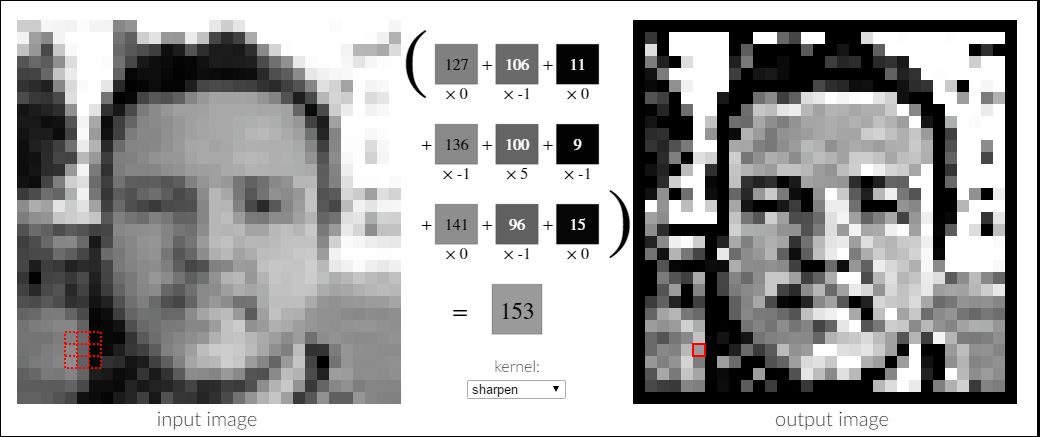

Si nos fijamos en la imagen de arriba, tenemos un cuadrado rojo. Ese cuadrado rojo es el "parche". El tamaño del parche será fijo. En este caso, el tamaño es de 3x3. Es parche recorre toda la imagen. Por pcada posición del parche, hay una neurona que utiliza esa región de la imagen. Es decir, esa región que está marcada en la imagen será utilizada por una neurona (o más).

- Esa región se le asigna a tantas neurona como filtros queramos usar. Por ejemplo, en este caso se está utilizando solo un filtro, el sharppen, que sirve para resaltar bordes. Pero si quisieramos aplicarle más filtros a la imagen original, por ejemplo, uno de textura, tendríamos DOS neuronas que utilizarían esa región de la imagen: la primera neurona usaría el filtro de sharppen (y devolvería una z, en este caso el 153 que se ve en la imagen) y la segunda neurona usaría otro filtro que devovlería otra z. 
- Ahora, el parche se moverá y conseguiremos una z nueva por filtro y por neurona.
- Importante comentar que el filtro que se aplica a cada parche es el mismo. Es decir, el valor de la matriz 3x3 con la que se hace la convolución tiene los mismos valores para todas las regiones del espacio. 
- Finalmente, todos esos valores se combinarán para generar un mapa de activación (la imagen de la derecha) por filtro. Cada imagen irá por un canal. Es decir, en este caso tendríamos un tensor (1, 128, 128) de entrada y un tensor (1, 64, 64) de salida (me he invtando los numeros). El 1 el número de canales (tantos canales como filtros distintos apliquemos), y el 128, 128 (o 64, 64) es el tamaño de la imagen como tal.
- Ahora, se suele hacer un ReLU como función de activación. Si los valores que consigues con el filtro son negativos, se ponen a 0 directamente, si no, se ponen con el valor que tienen.
- Luego, se puede hacer un pooling. En el pooling lo que haces es coger secciones de la imagen (como otro parche) y quedarte con alguno de los valores. Puede ser un MaxPooling (te quedas con el valor más grande del parche) o AveragePooling (te quedas con el promedio). Esto sirve para hacer la imagen más pequeña y quedarte con lo más "importante". Por ejemplo, si hacer un MaxPooling de 2, cogerías la imagne, la recorrerías con un parche de 2x2 y te quedaráis con el máximo. De está forma, haces la imagen 4 veces más pequeña (de 4 pixeles pasas a 1).
- También existen las capas dropout, que se UTILIZAN SOLO DURANTE EL ENTRENAMIENTO. Estas capas apagan de forma aleatoria algunas neuronas. De esta forma evitamos el sobreajuste, pues el modelo tiene que aprender a clasificar bien incluso sin neuronas que son realmente importante para esa clase.


- Una vez hechas todas estas capas, se pasa el nuevo tensor (los canales y toda la pesca) a la siguiente capa. Esto se repite tantas veces como se quiera.

- La última capa debería ser un flatten. Esto convierte el tensor con todos sus canales y tal en un vector de tamaño número_canalesXnúmero_alturaXnúmero_anchura. Luego, se hace un último nn.Linear(), como en MLP y se consiguen los logits de las posibles clases. Con esto conseguimos las probabilidades de pertenencia de cada clase.


Pero, ¿donde se aprende aquí? Es decir, en las MLP estaba claro que para aprender, se hacía el descenso del gradiente buscando minimizar la función de pérdida acmbiando poco a poco el valor de los pesos de las neuronas. Ahora, ¿qué es lo que se cambia?

- Lo que se cambia es el valor de la matriz que representa el filtro. Es decir, cada filtro se inicializa con valores aleatorios y estos se van ajustando con el descenso del gradiente tal que la función de pérdida se minimiza. Al final, muchos de esos filtros acaban siendo filtros conocidos como el sharppen o el texture.

Ese es un poco el flujo de trabajo de una CNN. Es parecido a una MLP por todo el tema de el cambio de pesos, los logits y tal pero esta vez se tiene en cuenta la posición de los píxeles en la imágen.

  


---
# Parte A - Introducción a las CNN

### Píldora teórica - ¿Qué son las CNN y por qué se utilizan?

Las **Redes Neuronales Convolucionales (CNNs)** son un tipo especial de red neuronal diseñado para procesar **datos en forma de imágenes**. A diferencia de las redes totalmente conectadas (fully connected), las CNNs pueden:

- Capturar **patrones espaciales** en la imagen, como bordes, texturas y formas.
- Ser **invariantes a traslaciones**, es decir, reconocer un objeto sin importar su posición en la imagen.
- **Reducir el número de parámetros**, haciendo el entrenamiento más eficiente y evitando overfitting.

![Ejemplo de una CNN](https://images.viblo.asia/f087aedf-817a-441f-801f-ddda5d695e31.png "Ejemplo de una CNN")

> **Las CNNs resuelven esto utilizando operaciones de convolución**, que permiten detectar características locales y combinarlas para reconocer patrones complejos.

### Píldora teórica - Nuevos tipos de capas en una CNN

#### 1. Capa de convolución

Aplica **filtros (kernels)** que recorren la imagen y **detectan características** como bordes, texturas o patrones.

**Parámetros clave:**
- **Número de filtros** (más filtros = mayor capacidad de aprendizaje).
- **Tamaño del kernel** (3x3, 5x5, etc.).
- **Stride** (paso): cuántos píxeles se mueve el filtro en cada paso.
- **Padding**: si se agregan ceros alrededor de la imagen para mantener el tamaño.

**Ejemplo:**

Convolución con `padding = 1` y `stride = 2`:

![2º ejemplo de convolución](https://maucher.home.hdm-stuttgart.de/Pics/gif/padding_strides.gif "padding = 1, stride = 2")

#### 2. Capa Dropout

Evita el **sobreajuste** **desactivando** aleatoriamente ciertas **neuronas** durante el entrenamiento.

**Ejemplo:**

![Ejemplo Dropout](https://nagadakos.github.io/images/dropout.gif "Ejemplo Dropout")

#### 3. Capa Pooling

**Reduce la dimensión de la imagen**, manteniendo solo la información más importante. Hace que la red sea más resistente a cambios pequeños en la imagen.

**Tipos:**
- **Max Pooling**: Toma el valor máximo en cada región.
- **Average Pooling**: Toma el promedio en cada región.

**Ejemplo:**

![Ejemplo Max Pooling](https://nico-curti.github.io/NumPyNet/NumPyNet/images/maxpool.gif "Ejemplo Max Pooling")

---
# Parte B - Modelo CNN base

In [ ]:
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

## 1) Demo - Preparación de datos

### Mini píldora teórica: `transforms.Compose()`

Esta función permite **aplicar** múltiples **transformaciones** a las **imágenes** de forma ordenada.

**Ejemplo:** `transforms.Normalize()`, que se utiliza para normalizar los píxeles de las imágenes.

Ayuda a que la red **converja más rápido** durante el entrenamiento y previene que ciertos canales de color dominen sobre otros si tienen rangos de valores muy diferentes.

> Los valores específicos $mean=(0.4914, 0.4822, 0.4465)$ y $std=(0.2470, 0.2435, 0.2616)$ son la media y desviación estándar por canal (R, G, B) precalculadas sobre el conjunto de datos **CIFAR-10**.

---
En esta práctica trabajaremos con `CIFAR-10` (60k imágenes 32x32 RGB, 10 clases). Se hará un *split* **train/val/test** y se prepararán los `DataLoaders` correspondientes.


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616)),
])

trainval_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_ds     = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

En torch, con el transforms.Compose lo que haces es aplicar transformaciones en cadena de forma sencilla. En este caso, las transformaciones a aplicar serían:

- ToTensor(): Conviente las imagenes de Cifar10 a tensor de Torch. Siempre hacerlo
- Normalize(): Normalizamos los datos. Centramos los datos en el 0, para evitar sesgos de activación y hacemos que la varianza de los datos sea de aproximadametne 1, para evitar gradientes muy grandes o muy pequeños.

In [ ]:
val_size = 5000
train_size = len(trainval_ds) - val_size
train_ds, val_ds = random_split(trainval_ds, [train_size, val_size],
                                generator=torch.Generator().manual_seed(SEED))

In [ ]:
BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

## 2) Demo - CNN base

Definición de una arquitectura **lo más simple posible**:

- **Entrada:** 3x32x32
- **Bloque convolucional:** `Conv2d → ReLU → MaxPool2d`
- **Clasificador:** `Flatten → Linear`

> La idea es que esta red sea solo el **punto de partida**.


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1), # 3x32x32 -> 16x32x32
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2), # 16x32x32 -> 16x16x16
            nn.Flatten(),
            nn.Linear(16 * 16 * 16, num_classes) # 16*16*16 -> 10
        )

    def forward(self, x):
        return self.net(x)

Esta es una red mínima. Tenemos una convolución 2D, una capa de activación ReLU, luego un MaxPooling en 2D, un flatten para pasar a vector y luego un Linear para conseguir logits de salida. 

También definimos el forward, para el entrenamiento juraría. Vamos a ver qué hace cada capa y para qué es:

- nn.Conv2d(número de canales de entrada, número de canales de salida, tamaño del parche, padding): El número de canales de entrada, para la primera capa, depende de si está en color o en blanco y negro. Si está en color, serían 3. Si está en blanco y negro, sería 1 canal. LUego, el número de canales de salida, es básicamente cuantos filtros quieres aplicar.
  - Ahora, al tener 3 canales, la cosa se complica un poco. No hay que pensar en los filtros como matrices, si no como tensores. Como tengo tres canales, tengo un tensor 3x3x3. El primer 3 hace referencia al número de canales, y luego el 3x3 es el tamaño de cada filtro. Por lo tanto, el filtro tendrá en realidad diferentes valores en función del canal. Es decir, el filtro son 3 matrices 3x3, cada una especializada en cada canal. Podría pensarse que son tres filtros, pero es uno, solo que como es un tensor es un poco más dificil de imaginar.
  - En cada parche, el filtro hace z=(R⋅WR​)+(G⋅WG​)+(B⋅WB​)+b, donde R es la matriz 3x3 de la imagen en el canal rojo y WR es la matriz 3x3 del filtro para el canal rojo. Lo mismo con el resto de canal. Luego, sacas la z.
  - Ahora, como tenemos el padding = 1, que lo que hace es añadir un cuadrado de 0 alrededor de la imagen, el tamaño final de la imagen no cambia, sigue siendo 32x32, pero esta vez con 16 canales
  - También hemos "perdido" la imagen a color. Ahora tenemos una imagen con 16 canales. Cada canal ha aprendido algo sobre la imagen digamos.
- nn.ReLU(): Aplicamos ReLU() para no tener logits todavía. Con esto, conseguimos la activación de las neuronas. Con esto introducimos no linealidades.
- nn.MaxPool2d(tamaño_kernel): Introducimos un MaxPooling para quedamos con el pixel más importante de cada canal en una ventana de 2x2. Así, reducimos el tamño de la imagen y también introducimos invarianza. Si hay un pequeño cambio en la imagen, no afecta tanto.
- Seguimos con el nn.Flatten(), que conviente el tensor en una vector
- Acabamos con nn.Linear para transformar el vector en logits por ultima vez.


Y, ¿cómo es el entrenamiento en esta red?

- Los pesos que se ajustan son los de la capa nn.Linear() y los de los filtros de Conv2d.

In [ ]:
model = SimpleCNN().to(device)
print(model)

In [ ]:
# Comprobación rápida de shapes con un batch
images, labels = next(iter(train_loader))
images = images.to(device)
out = model(images)
print("Input:", images.shape, "Output:", out.shape)

## 3) Demo - Funciones de entrenamiento y evaluación

Estas funciones deben usarse tanto para el modelo CNN base ya generado como para cualquier modelo CNN más avanzado que se construya más adelante.


In [ ]:
def evaluate(model, dataloader, criterion, device=device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            loss = criterion(output, labels)

            running_loss += loss.item()
            _, preds = torch.max(output, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = 100.0 * correct / total
    avg_loss = running_loss / len(dataloader)
    return avg_loss, accuracy

Este código evalua un modelo. Solo define la función de evalución que se utilizará más tarde. 

- Empieza poniendo el modelo en modo evaluación el model.eval(). Esto desactiva el dropout, lo de apagar neuronas aleatorias.
- Inicia constantes de evaluación: el loss, cuantas correctas hay y el total.
- Usamos torch.no_grad(), lo cual desactiva el cálculo del grandiente, acelerando los cálculos y así el proceso de evaluación.
- Empezamos iterando por batches. Del dataloader, sacamos las imágenes y el label. Luego, enviamos cada una al device.
- Conseguimos el output del modelo llamando al modelo con las imagenes. Luego, calculamos el loss con el criterio de evalución que desee el usuario con el criterion y comparamos el output con los labels reales.
- Sumamos el loss de esta sesión y lo pasamos a escalar con .item()
- Conseguimos la predicción cogiendo el logit que más alto sea. Luego, miramos si son correctos y sumamos 1 si ha sido correcto.
- Calculamos el total de predicciones hechas.
- Calculamos el accuracy con el correct/total y el loss medio.


In [ ]:
def train(model, trainloader, valloader, optimizer, criterion, epochs=10, device=device):
    for epoch in range(epochs):
        model.train()
        epoch_start = time.time()
        running_loss = 0.0
        correct = 0
        total = 0

        # --- Entrenamiento ---
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(output, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_accuracy = 100.0 * correct / total
        avg_train_loss = running_loss / len(trainloader)

        # --- Validación ---
        val_loss, val_accuracy = evaluate(model, valloader, criterion, device=device)
        epoch_time = time.time() - epoch_start

        print(
            f"Época {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.3f} - Train Acc: {train_accuracy:.2f}% | "
            f"Val Loss: {val_loss:.3f} - Val Acc: {val_accuracy:.2f}% | "
            f"Tiempo: {epoch_time:.2f}s"
        )

    return model

Esta función es la que nos entrena la red y nos devuelve el modelo final para evaluar y utilizar.

- Primero ponemos el modelo en modo train. Esto es para activar el dropout. También definimos algunas constantes como antes para medir el rendimiento del entrenamiento.
- El model se entrena por épocas. En una época, se pasa el dataset de train completo al modelo una vez. En cada época, los párametros del modelo se ajustan en cada batch. El número de épocas al final es cuantas veces quiers que el modelo itere y se entrene sobre el mismo subconjuto de datos. 
- El entrenamiento real empieza en el segundo for, cuando itera por batches. Primeo se mandan tanto las imágenes como los labels al device.
- Luego se borran los gradientes, ya que torch acumula gradientes en memoría. Para poder ahcer bien el entrenamiento, hay que eliminarlos en cada batch.
- Se obtienen los logits con el output, luego se consigue el loss comparando el loss con los labels reales.
- Ahora es cuando realmente sucede todo, con el loss.backward(). Se llevan hacia atrás ese loss y es cuando ocurre la optimización del modelo como tal. Se calcula el gradiente para los filtros y para el nn.Linear. Con el optimizer.step(), se actualizan los pesos. Esto es el core del aprendizaje: el forward (output), el loss, el backpropagation (el .backward) y el update (el .step()).
- Luego se aprovecha para calcuar el número de corecctos y tal para después calcular el accuracy del train.
- Finalmetne, se evalua el modelo con la función de antes, utilizando el conjunto de validación. Ahí se mide que tan bueno o no es el modelo. Gracias a esto ,podemos hacer un stop previo si vemos que durante X épocas el modelo no mejora. 
- Se repite hasta acabar con los epochs o hasta no encontrar mejoría.

In [ ]:
def evaluate_on_test(model, testloader, criterion, device=device):
    test_loss, test_acc = evaluate(model, testloader, criterion, device=device)
    print(f"\nTest Loss: {test_loss:.3f} | Test Acc: {test_acc:.2f}%")
    return test_loss, test_acc

Se evalua el modelo una ultima vez, esta vez utilizando el conjunto de test, nunca antes visto durante el entrenamiento.

## 4) Demo - Entrenamiento y evaluación del modelo base

Lo esperable es que la CNN mínima no sea puntera, pero supere un MLP comparable porque aprovecha la estructura espacial de las imágenes.


In [ ]:
# Hiperparámetros base
EPOCHS = 8
LR = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [ ]:
# Entrenamiento + test
model = train(model, train_loader, val_loader, optimizer, criterion, epochs=EPOCHS, device=device)
_ = evaluate_on_test(model, test_loader, criterion, device=device)

---
# Parte C - Construcción de modelos CNN avanzados

## 5) Ejercicio - Mejorar la arquitectura e hiperparámetros

Ahora ya que se ha visto un ejemplo de entrenamiento y evaluación de una CNN básica, es momento de **experimentar** e intentar crear una CNN que dé **mejores resultados**.

> **Objetivo:** crear una arquitectura de la CNN más avanzada, que junto a hiperparámetros optimizados, consiga mejorar el rendimiento del modelo base.

**Expectativas:**
- `Accuracy 80%-86%` → resultado normal
- `Accuracy 87%-91%` → resultado bueno
- `Accuracy 92%-100%` → resultado excelente

*(sobre el conjunto de test)*

---

#### Ideas a explorar
- Modificar el número de filtros en las capas convolucionales, los tamaños de kernel, los strides y paddings.
- Añadir más bloques convolucionales `Conv2d → ReLU → (Pool)`.
- Añadir `Dropout` en el clasificador.
- Añadir `BatchNorm2d` después de `Conv2d`.
- Cambiar el clasificador: `Linear → ReLU → Dropout → Linear`.
- Probar distintas funciones de activación.
- Probar `Average Pooling` en lugar de `Max Pooling` en determinados puntos de la arquitectura.
- Modificar el `batch_size` de los `DataLoader`.


In [ ]:
class MyCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            # TODO
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
my_model = MyCNN().to(device)

BATCH_SIZE = # TODO
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

epochs = # TODO
learning_rate = # TODO
criterion = # TODO
optimizer = # TODO

In [ ]:
my_model = train(my_model, train_loader, val_loader, optimizer, criterion, epochs=epochs, device=device)
_ = evaluate_on_test(my_model, test_loader, criterion, device=device)